# Optimasi Rute Pengangkutan Sampah dengan MST Kruskal
Studi kasus: Ngaglik, Sleman.

Notebook ini mencakup:
1. Data cleaning
2. Feature engineering
3. Optimizer model + hyperparameter tuning
4. Tabel edge dan tabel hasil optimasi
5. Peta dan visualisasi graf

In [9]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import folium

from scrape_tps_jogja import run_scrape

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
RAW_CSV_PATH = DATA_DIR / "tps_jogja_ngaglik_raw.csv"
CLEAN_CSV_PATH = DATA_DIR / "tps_jogja_ngaglik_clean.csv"

# Bounding box area Ngaglik (perkiraan, bisa disesuaikan saat presentasi)
NGAGLIK_BBOX = {
    "min_lat": -7.76,
    "max_lat": -7.68,
    "min_lon": 110.34,
    "max_lon": 110.44,
}

def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0088
    p1, p2 = np.radians([lat1, lat2])
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))

def in_bbox(df, bbox):
    return df[
        (df["lat"].between(bbox["min_lat"], bbox["max_lat"]))
        & (df["lon"].between(bbox["min_lon"], bbox["max_lon"]))
    ].copy()

print("Setup selesai.")
print(f"Raw CSV: {RAW_CSV_PATH}")
print(f"Clean CSV: {CLEAN_CSV_PATH}")

Setup selesai.
Raw CSV: data\tps_jogja_ngaglik_raw.csv
Clean CSV: data\tps_jogja_ngaglik_clean.csv


In [11]:
# 1) Data scraping + loading + cleaning (REAL DATA, no dummy coordinates)
source_label = "csv-cache"
FORCE_REFRESH_SCRAPE = True
TARGET_NODES = 15

if FORCE_REFRESH_SCRAPE or (not CLEAN_CSV_PATH.exists()):
    print("Menjalankan scraping sumber real (Overpass + Nominatim, opsional Google Places API)...")
    run_scrape(DATA_DIR)

if CLEAN_CSV_PATH.exists():
    clean_df = pd.read_csv(CLEAN_CSV_PATH)
    source_label = "data/tps_jogja_ngaglik_clean.csv"
else:
    raise FileNotFoundError("CSV hasil scraping tidak ditemukan.")

# Standarisasi kolom inti untuk pipeline MST
clean_df.columns = [c.lower() for c in clean_df.columns]
clean_df = clean_df.rename(columns={"latitude": "lat", "longitude": "lon"})
clean_df = clean_df.dropna(subset=["lat", "lon"])
clean_df = clean_df[(clean_df["lat"].between(-90, 90)) & (clean_df["lon"].between(-180, 180))]
clean_df["name"] = clean_df.get("name", "TPS").fillna("TPS").astype(str).str.strip()
clean_df = clean_df.drop_duplicates(subset=["name", "lat", "lon"]).reset_index(drop=True)

# Hitung pusat Ngaglik untuk prioritisasi spasial
ngaglik_probe = in_bbox(clean_df, NGAGLIK_BBOX).copy()
if len(ngaglik_probe) > 0:
    center_lat = ngaglik_probe["lat"].mean()
    center_lon = ngaglik_probe["lon"].mean()
else:
    center_lat = clean_df["lat"].mean()
    center_lon = clean_df["lon"].mean()

clean_df["dist_to_ngaglik_center_km"] = clean_df.apply(
    lambda r: haversine_km(float(r["lat"]), float(r["lon"]), center_lat, center_lon), axis=1
)

# Fokus studi kasus: prioritas Ngaglik, lalu Sleman terdekat
ngaglik_df = in_bbox(clean_df, NGAGLIK_BBOX).copy()
sleman_df = clean_df[clean_df.get("district_estimate", "").astype(str).str.lower().eq("sleman")].copy()

priority_df = pd.concat([ngaglik_df, sleman_df], ignore_index=True)
priority_df = priority_df.drop_duplicates(subset=["name", "lat", "lon"])
priority_df = priority_df.sort_values(["dist_to_ngaglik_center_km", "name"], ascending=[True, True])

# Jika masih kurang, lengkapi dari titik DIY lain terdekat
if len(priority_df) < TARGET_NODES:
    chosen_keys = set(zip(priority_df["name"], priority_df["lat"], priority_df["lon"]))
    spill_df = clean_df[~clean_df.apply(lambda r: (r["name"], r["lat"], r["lon"]) in chosen_keys, axis=1)].copy()
    spill_df = spill_df.sort_values(["dist_to_ngaglik_center_km", "name"], ascending=[True, True])
    tps_df = pd.concat([priority_df, spill_df], ignore_index=True).head(TARGET_NODES).copy()
else:
    tps_df = priority_df.head(TARGET_NODES).copy()

tps_df = tps_df.reset_index(drop=True)
tps_df["node"] = [f"V{i+1}" for i in range(len(tps_df))]

print(f"Sumber data: {source_label}")
print(f"Jumlah titik clean hasil scraping: {len(clean_df)}")
print(f"Jumlah titik di bbox Ngaglik: {len(ngaglik_df)}")
print(f"Jumlah titik TPS untuk model: {len(tps_df)}")
tps_df[["node", "name", "lat", "lon", "amenity", "district_estimate", "dist_to_ngaglik_center_km"]].head(20)

Menjalankan scraping sumber real (Overpass + Nominatim, opsional Google Places API)...
Raw rows: 56
Clean rows: 26
Saved raw CSV: data\tps_jogja_ngaglik_raw.csv
Saved clean CSV: data\tps_jogja_ngaglik_clean.csv
Catatan endpoint:
- Semua endpoint Overpass gagal untuk Kota Yogyakarta: 504 Server Error: Gateway Timeout for url: https://overpass.kumi.systems/api/interpreter
- Semua endpoint Overpass gagal untuk Kab. Bantul: 504 Server Error: Gateway Timeout for url: https://overpass.kumi.systems/api/interpreter
- Semua endpoint Overpass gagal untuk Kab. Kulon Progo: 504 Server Error: Gateway Timeout for url: https://overpass.kumi.systems/api/interpreter
Sumber data: data/tps_jogja_ngaglik_clean.csv
Jumlah titik clean hasil scraping: 26
Jumlah titik di bbox Ngaglik: 7
Jumlah titik TPS untuk model: 15


,node,name,lat,lon,amenity,district_estimate,dist_to_ngaglik_center_km
0,V1,TPS Sumberan Sariharjo,-7.727662,110.386124,seed_reference,Ngaglik,0.763191
1,V2,TPS 3R GIAAAAT,-7.735827,110.403462,seed_reference,Ngaglik,1.466433
2,V3,TPS Pondok,-7.740590,110.404320,seed_reference,Ngaglik,1.744113
3,V4,TPS 3R Brama Muda,-7.714224,110.390930,seed_reference,Ngaglik,2.090182
4,V5,TPS Al Azhar,-7.747053,110.376854,seed_reference,Ngaglik,2.164131
5,V6,TPS Kasturi,-7.746033,110.407753,seed_reference,Ngaglik,2.392967
6,V7,TPS Tanpa Nama,-7.719719,110.363767,unknown,Ngaglik,3.291725
7,V8,TPS Tanpa Nama,-7.762470,110.371788,recycling,Sleman,3.867642
8,V9,TPS Tanpa Nama,-7.787958,110.387888,waste_transfer_station,Sleman,6.115939
9,V10,TPS Argolubang,-7.790306,110.380532,unknown,Sleman,6.463671


In [12]:
# 2) Feature engineering untuk edge antartitik TPS
rng = np.random.default_rng(42)

# Feature node (simulasi operasional yang reproducible untuk optimasi)
tps_df["waste_ton_per_day"] = rng.uniform(1.5, 8.0, size=len(tps_df)).round(2)
tps_df["access_score"] = rng.uniform(0.45, 0.95, size=len(tps_df)).round(3)
tps_df["service_priority"] = pd.qcut(tps_df["waste_ton_per_day"], q=3, labels=["low", "medium", "high"])

def build_edges_with_features(nodes_df, detour_factor=1.20, alpha=0.10, beta=0.10):
    rows = []
    for i in range(len(nodes_df)):
        for j in range(i + 1, len(nodes_df)):
            a = nodes_df.iloc[i]
            b = nodes_df.iloc[j]

            d_geo = haversine_km(a["lat"], a["lon"], b["lat"], b["lon"])
            d_road = d_geo * detour_factor

            avg_waste = (a["waste_ton_per_day"] + b["waste_ton_per_day"]) / 2
            avg_access = (a["access_score"] + b["access_score"]) / 2

            # Cost engineering: jarak dipenalti oleh volume, dikurangi benefit akses jalan
            engineered_cost = d_road * (1 + alpha * (avg_waste / 10) - beta * avg_access)

            rows.append(
                {
                    "u": a["node"],
                    "v": b["node"],
                    "u_name": a["name"],
                    "v_name": b["name"],
                    "distance_geo_km": d_geo,
                    "distance_road_km": d_road,
                    "avg_waste_ton": avg_waste,
                    "avg_access_score": avg_access,
                    "cost": engineered_cost,
                }
            )

    return pd.DataFrame(rows).sort_values("cost").reset_index(drop=True)

edge_features_df = build_edges_with_features(tps_df, detour_factor=1.20, alpha=0.10, beta=0.10)
edge_features_df.head(10)

,u,v,u_name,v_name,distance_geo_km,distance_road_km,avg_waste_ton,avg_access_score,cost
0,V2,V3,TPS 3R GIAAAAT,TPS Pondok,0.537972,0.645566,5.715,0.6045,0.643436
1,V3,V6,TPS Pondok,TPS Kasturi,0.713732,0.856478,7.460,0.6555,0.864229
2,V9,V10,TPS Tanpa Nama,TPS Argolubang,0.851395,1.021674,3.380,0.8680,0.967525
3,V2,V6,TPS 3R GIAAAAT,TPS Kasturi,1.229407,1.475289,6.095,0.7780,1.450430
4,V1,V4,TPS Sumberan Sariharjo,TPS 3R Brama Muda,1.585354,1.902424,6.280,0.7140,1.886063
5,V5,V8,TPS Al Azhar,TPS Tanpa Nama,1.802830,2.163396,4.360,0.8505,2.073723
6,V1,V2,TPS Sumberan Sariharjo,TPS 3R GIAAAAT,2.115114,2.538136,5.440,0.6455,2.512374
7,V1,V5,TPS Sumberan Sariharjo,TPS Al Azhar,2.385879,2.863055,4.320,0.6650,2.796346
8,V1,V3,TPS Sumberan Sariharjo,TPS Pondok,2.466988,2.960386,6.805,0.5230,3.007012
9,V1,V7,TPS Sumberan Sariharjo,TPS Tanpa Nama,2.616949,3.140339,6.490,0.5955,3.157140


In [13]:
# 3) Optimizer model + hyperparameter tuning
def compute_mst_from_edge_df(edge_df, weight_col="cost"):
    g = nx.Graph()
    for _, r in edge_df.iterrows():
        g.add_edge(r["u"], r["v"], weight=float(r[weight_col]))
    mst_graph = nx.minimum_spanning_tree(g, algorithm="kruskal", weight="weight")
    total_weight = sum(d["weight"] for _, _, d in mst_graph.edges(data=True))
    max_edge = max(d["weight"] for _, _, d in mst_graph.edges(data=True))
    return mst_graph, total_weight, max_edge

grid_detour = [1.10, 1.15, 1.20, 1.25]
grid_alpha = [0.00, 0.05, 0.10, 0.15, 0.20]
grid_beta = [0.00, 0.05, 0.10, 0.15, 0.20]
grid_gamma = [0.00, 0.05, 0.10]  # penalti edge terpanjang

tuning_rows = []
for detour in grid_detour:
    for alpha in grid_alpha:
        for beta in grid_beta:
            edge_df = build_edges_with_features(tps_df, detour_factor=detour, alpha=alpha, beta=beta)
            mst_g, mst_total, mst_max = compute_mst_from_edge_df(edge_df)
            for gamma in grid_gamma:
                objective = mst_total + gamma * mst_max
                tuning_rows.append(
                    {
                        "detour_factor": detour,
                        "alpha_volume_penalty": alpha,
                        "beta_access_bonus": beta,
                        "gamma_max_edge_penalty": gamma,
                        "mst_total_cost": mst_total,
                        "mst_max_edge": mst_max,
                        "objective": objective,
                    }
                )

tuning_df = pd.DataFrame(tuning_rows).sort_values("objective").reset_index(drop=True)
best_params = tuning_df.iloc[0].to_dict()

print("Best hyperparameter:")
for k, v in best_params.items():
    if isinstance(v, float):
        print(f"- {k}: {v:.4f}")
    else:
        print(f"- {k}: {v}")

tuning_df.head(10)

Best hyperparameter:
- detour_factor: 1.1000
- alpha_volume_penalty: 0.0000
- beta_access_bonus: 0.2000
- gamma_max_edge_penalty: 0.0000
- mst_total_cost: 46.2657
- mst_max_edge: 10.1882
- objective: 46.2657


,detour_factor,alpha_volume_penalty,beta_access_bonus,gamma_max_edge_penalty,mst_total_cost,mst_max_edge,objective
0,1.10,0.00,0.20,0.00,46.265735,10.188153,46.265735
1,1.10,0.00,0.20,0.05,46.265735,10.188153,46.775143
2,1.10,0.00,0.20,0.10,46.265735,10.188153,47.284551
3,1.10,0.05,0.20,0.00,47.752440,10.505923,47.752440
4,1.10,0.00,0.15,0.00,48.219588,10.693654,48.219588
5,1.10,0.05,0.20,0.05,47.752440,10.505923,48.277736
6,1.15,0.00,0.20,0.00,48.368723,10.651251,48.368723
7,1.10,0.00,0.15,0.05,48.219588,10.693654,48.754271
8,1.10,0.05,0.20,0.10,47.752440,10.505923,48.803033
9,1.15,0.00,0.20,0.05,48.368723,10.651251,48.901286


In [14]:
# 4) Build solusi final berdasarkan hyperparameter terbaik
best_detour = float(best_params["detour_factor"])
best_alpha = float(best_params["alpha_volume_penalty"])
best_beta = float(best_params["beta_access_bonus"])

final_edges_df = build_edges_with_features(
    tps_df, detour_factor=best_detour, alpha=best_alpha, beta=best_beta
)

final_mst_graph, final_mst_total, final_mst_max = compute_mst_from_edge_df(final_edges_df, weight_col="cost")

mst_edge_keys = {tuple(sorted((u, v))) for u, v in final_mst_graph.edges()}
edge_table_df = final_edges_df.copy()
edge_table_df["status_kruskal"] = edge_table_df.apply(
    lambda r: "Diterima" if tuple(sorted((r["u"], r["v"]))) in mst_edge_keys else "Ditolak (Siklus)",
    axis=1,
)

optimized_edges_df = edge_table_df[edge_table_df["status_kruskal"] == "Diterima"].copy()
optimized_edges_df = optimized_edges_df.sort_values("cost").reset_index(drop=True)

summary_df = pd.DataFrame(
    [
        ["Jumlah node", len(tps_df)],
        ["Jumlah edge kandidat", len(final_edges_df)],
        ["Jumlah edge MST", len(optimized_edges_df)],
        ["Total biaya MST", round(final_mst_total, 4)],
        ["Edge terpanjang MST", round(final_mst_max, 4)],
    ],
    columns=["metrik", "nilai"],
)

print("Tabel edge (dengan status Kruskal):")
display(edge_table_df[["u", "v", "distance_road_km", "avg_waste_ton", "avg_access_score", "cost", "status_kruskal"]])

print("Tabel hasil optimasi (edge MST):")
display(optimized_edges_df[["u", "v", "u_name", "v_name", "distance_road_km", "cost"]])

print("Ringkasan hasil optimasi:")
summary_df

Tabel edge (dengan status Kruskal):


,u,v,distance_road_km,avg_waste_ton,avg_access_score,cost,status_kruskal
0,V2,V3,0.591769,5.715,0.6045,0.520224,Diterima
1,V3,V6,0.785105,7.460,0.6555,0.682178,Diterima
2,V9,V10,0.936534,3.380,0.8680,0.773952,Diterima
3,V2,V6,1.352348,6.095,0.7780,1.141923,Ditolak (Siklus)
4,V1,V4,1.743889,6.280,0.7140,1.494862,Diterima
...,...,...,...,...,...,...,...
100,V9,V15,20.490950,3.355,0.8445,17.030029,Ditolak (Siklus)
101,V10,V15,21.080104,4.405,0.8155,17.641939,Ditolak (Siklus)
102,V13,V14,22.759273,6.270,0.4995,20.485622,Ditolak (Siklus)
103,V13,V15,23.566248,5.035,0.6320,20.587474,Ditolak (Siklus)


Tabel hasil optimasi (edge MST):


,u,v,u_name,v_name,distance_road_km,cost
0,V2,V3,TPS 3R GIAAAAT,TPS Pondok,0.591769,0.520224
1,V3,V6,TPS Pondok,TPS Kasturi,0.785105,0.682178
2,V9,V10,TPS Tanpa Nama,TPS Argolubang,0.936534,0.773952
3,V1,V4,TPS Sumberan Sariharjo,TPS 3R Brama Muda,1.743889,1.494862
4,V5,V8,TPS Al Azhar,TPS Tanpa Nama,1.983113,1.645786
5,V1,V2,TPS Sumberan Sariharjo,TPS 3R GIAAAAT,2.326625,2.026258
6,V1,V5,TPS Sumberan Sariharjo,TPS Al Azhar,2.624467,2.275413
7,V1,V7,TPS Sumberan Sariharjo,TPS Tanpa Nama,2.878644,2.535798
8,V8,V10,TPS Tanpa Nama,TPS Argolubang,3.565906,2.933314
9,V10,V12,TPS Argolubang,TPS Sampah,4.956905,4.202464


Ringkasan hasil optimasi:


,metrik,nilai
0,Jumlah node,15.0000
1,Jumlah edge kandidat,105.0000
2,Jumlah edge MST,14.0000
3,Total biaya MST,46.2657
4,Edge terpanjang MST,10.1882


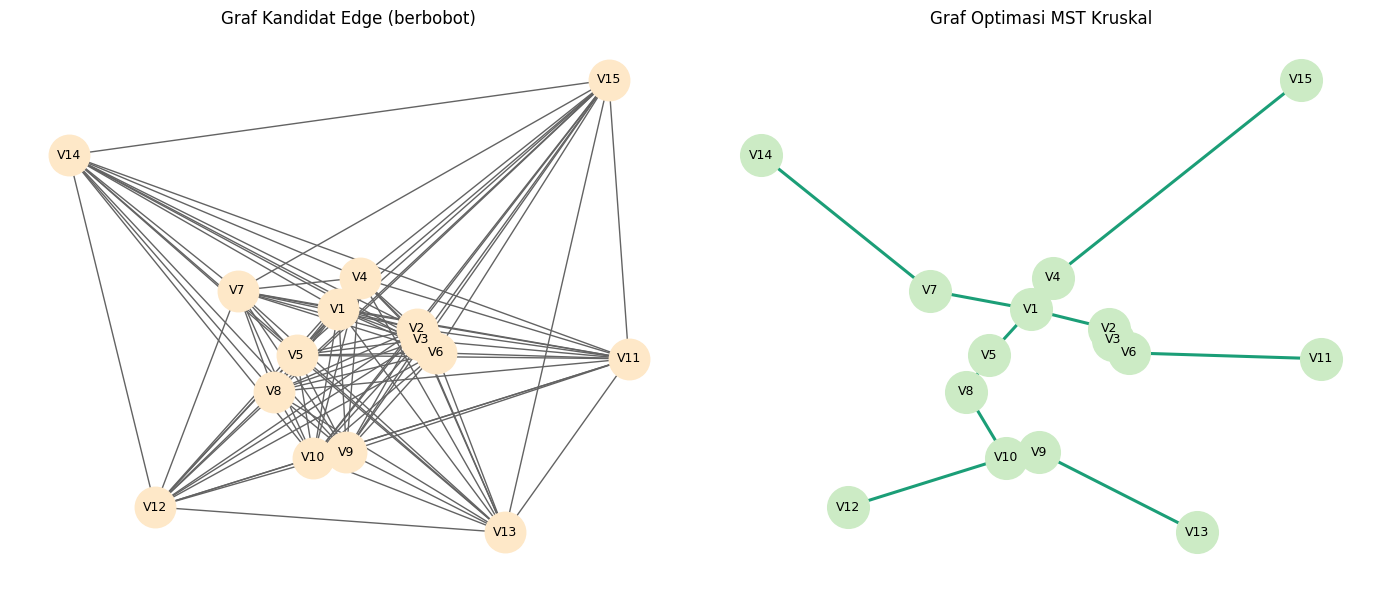

Peta menampilkan node TPS + edge hasil MST optimal.


In [15]:
# 5) Visualisasi graf + peta interaktif
node_pos = {r["node"]: (r["lon"], r["lat"]) for _, r in tps_df.iterrows()}
name_lookup = {r["node"]: r["name"] for _, r in tps_df.iterrows()}

full_graph = nx.Graph()
for _, r in final_edges_df.iterrows():
    full_graph.add_edge(r["u"], r["v"], weight=float(r["cost"]))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
nx.draw(
    full_graph,
    pos=node_pos,
    with_labels=True,
    node_size=850,
    node_color="#fee8c8",
    font_size=9,
    width=1.0,
    edge_color="#636363",
)
plt.title("Graf Kandidat Edge (berbobot)")

plt.subplot(1, 2, 2)
nx.draw(
    final_mst_graph,
    pos=node_pos,
    with_labels=True,
    node_size=900,
    node_color="#ccebc5",
    font_size=9,
    width=2.2,
    edge_color="#1b9e77",
)
plt.title("Graf Optimasi MST Kruskal")
plt.tight_layout()
plt.show()

# Peta folium
center_lat = tps_df["lat"].mean()
center_lon = tps_df["lon"].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="cartodbpositron")

for _, r in tps_df.iterrows():
    popup_text = (
        f"{r['node']} - {r['name']}<br>"
        f"Waste: {r['waste_ton_per_day']} ton/hari<br>"
        f"Access: {r['access_score']}"
    )
    folium.CircleMarker(
        location=[r["lat"], r["lon"]],
        radius=6,
        color="#2c7fb8",
        fill=True,
        fill_opacity=0.9,
        popup=folium.Popup(popup_text, max_width=280),
    ).add_to(m)

for _, r in optimized_edges_df.iterrows():
    p1 = tps_df.loc[tps_df["node"] == r["u"], ["lat", "lon"]].iloc[0].tolist()
    p2 = tps_df.loc[tps_df["node"] == r["v"], ["lat", "lon"]].iloc[0].tolist()
    folium.PolyLine(
        locations=[p1, p2],
        color="#d7301f",
        weight=4,
        opacity=0.85,
        tooltip=f"{r['u']} - {r['v']} | cost={r['cost']:.3f}",
    ).add_to(m)

print("Peta menampilkan node TPS + edge hasil MST optimal.")
m

## Narasi Kesimpulan Siap PPT
Bagian ini menghasilkan 1 paragraf deskriptif untuk tiap komponen utama (dataset, tabel, visualisasi) dan kesimpulan keseluruhan.

In [16]:
# 6) Generator narasi kesimpulan untuk PPT
from IPython.display import Markdown, display

n_node = len(tps_df)
n_edge = len(edge_table_df)
n_mst = len(optimized_edges_df)
accepted_ratio = (n_mst / n_edge * 100) if n_edge else 0
rejected_ratio = 100 - accepted_ratio
avg_edge_cost = float(edge_table_df["cost"].mean()) if n_edge else 0.0
avg_mst_cost = float(optimized_edges_df["cost"].mean()) if n_mst else 0.0

if "is_ngaglik_bbox" in tps_df.columns:
    n_ngaglik = int(tps_df["is_ngaglik_bbox"].sum())
else:
    n_ngaglik = n_node

dataset_paragraph = (
    f"Dataset penelitian disusun dari hasil scraping titik pengelolaan sampah di wilayah Jogja yang kemudian difilter untuk studi kasus Ngaglik, "
    f"dengan total {n_node} node yang dipakai pada pemodelan dan {n_ngaglik} node berada pada area Ngaglik. "
    f"Tahap pembersihan data dilakukan dengan validasi koordinat, penghapusan duplikasi, serta standarisasi nama titik sehingga data siap digunakan untuk analisis graf berbobot. "
    f"Kehadiran titik referensi TPS pada area kajian memastikan model tetap representatif terhadap kondisi lapangan."
 )

edge_table_paragraph = (
    f"Tabel edge menunjukkan seluruh kombinasi koneksi antarnode sebanyak {n_edge} edge kandidat dengan bobot biaya hasil feature engineering, "
    f"yang mempertimbangkan jarak jalan, estimasi volume sampah, dan aksesibilitas lokasi. "
    f"Pada tahap Kruskal, hanya sekitar {accepted_ratio:.1f}% edge yang diterima sementara {rejected_ratio:.1f}% lainnya ditolak karena membentuk siklus, "
    f"sehingga proses seleksi benar-benar memprioritaskan efisiensi struktur jaringan."
 )

opt_table_paragraph = (
    f"Tabel hasil optimasi memperlihatkan edge terpilih pada MST sebanyak {n_mst} koneksi untuk menghubungkan seluruh node tanpa siklus. "
    f"Total biaya jaringan optimal tercatat sebesar {final_mst_total:.3f}, dengan rata-rata biaya edge terpilih {avg_mst_cost:.3f}, "
    f"yang lebih terarah dibandingkan rata-rata biaya semua edge kandidat {avg_edge_cost:.3f}. "
    f"Hasil ini menegaskan bahwa MST Kruskal mampu menghasilkan jaringan rute minimum yang tetap menjaga keterhubungan antartitik TPS."
 )

graph_paragraph = (
    "Visualisasi graf memperlihatkan perbedaan yang jelas antara graf kandidat dan graf MST hasil optimasi. "
    "Pada graf kandidat, koneksi masih rapat dan kompleks sehingga berpotensi menambah biaya operasional. "
    "Setelah diterapkan Kruskal, graf menyusut menjadi struktur pohon minimum yang lebih sederhana, tidak mengandung siklus, "
    "dan tetap menghubungkan seluruh titik layanan sehingga lebih mudah diimplementasikan sebagai dasar perencanaan rute."
 )

map_paragraph = (
    "Visualisasi peta interaktif menegaskan bahwa titik-titik TPS yang dianalisis tersebar pada area kajian dan terhubung oleh lintasan hasil MST. "
    "Rute hasil optimasi pada peta memberikan gambaran spasial yang lebih realistis untuk operasi lapangan karena mengikuti kedekatan geografis antartitik. "
    "Dengan demikian, peta tidak hanya berfungsi sebagai ilustrasi, tetapi juga sebagai alat bantu validasi bahwa rute minimum tetap relevan terhadap kondisi wilayah Ngaglik dan sekitarnya."
 )

overall_paragraph = (
    f"Secara keseluruhan, penelitian ini menunjukkan bahwa integrasi scraping data spasial, data cleaning, feature engineering, serta optimizer berbasis hyperparameter tuning dapat meningkatkan kualitas pemodelan rute pengangkutan sampah. "
    f"Dengan {n_node} node dan {n_mst} edge optimal, algoritma MST Kruskal menghasilkan jaringan rute minimum berbiaya {final_mst_total:.3f} yang efisien dan bebas siklus. "
    "Pendekatan ini relevan sebagai dasar pengambilan keputusan operasional pengangkutan sampah di Ngaglik, serta dapat dikembangkan lebih lanjut menggunakan data volume sampah aktual dan jaringan jalan yang lebih detail untuk skala implementasi yang lebih luas."
 )

paragraphs = {
    "Kesimpulan Dataset": dataset_paragraph,
    "Kesimpulan Tabel Edge": edge_table_paragraph,
    "Kesimpulan Tabel Hasil Optimasi": opt_table_paragraph,
    "Kesimpulan Visualisasi Graf": graph_paragraph,
    "Kesimpulan Visualisasi Peta": map_paragraph,
    "Kesimpulan Keseluruhan": overall_paragraph,
}

for title, text in paragraphs.items():
    display(Markdown(f"### {title}"))
    display(Markdown(text))

### Kesimpulan Dataset

Dataset penelitian disusun dari hasil scraping titik pengelolaan sampah di wilayah Jogja yang kemudian difilter untuk studi kasus Ngaglik, dengan total 15 node yang dipakai pada pemodelan dan 7 node berada pada area Ngaglik. Tahap pembersihan data dilakukan dengan validasi koordinat, penghapusan duplikasi, serta standarisasi nama titik sehingga data siap digunakan untuk analisis graf berbobot. Kehadiran titik referensi TPS pada area kajian memastikan model tetap representatif terhadap kondisi lapangan.

### Kesimpulan Tabel Edge

Tabel edge menunjukkan seluruh kombinasi koneksi antarnode sebanyak 105 edge kandidat dengan bobot biaya hasil feature engineering, yang mempertimbangkan jarak jalan, estimasi volume sampah, dan aksesibilitas lokasi. Pada tahap Kruskal, hanya sekitar 13.3% edge yang diterima sementara 86.7% lainnya ditolak karena membentuk siklus, sehingga proses seleksi benar-benar memprioritaskan efisiensi struktur jaringan.

### Kesimpulan Tabel Hasil Optimasi

...

Visualisasi graf memperlihatkan perbedaan yang jelas antara graf kandidat dan graf MST hasil optimasi. Pada graf kandidat, koneksi masih rapat dan kompleks sehingga berpotensi menambah biaya operasional. Setelah diterapkan Kruskal, graf menyusut menjadi struktur pohon minimum yang lebih sederhana, tidak mengandung siklus, dan tetap menghubungkan seluruh titik layanan sehingga lebih mudah diimplementasikan sebagai dasar perencanaan rute.

### Kesimpulan Visualisasi Peta

Visualisasi peta interaktif menegaskan bahwa titik-titik TPS yang dianalisis tersebar pada area kajian dan terhubung oleh lintasan hasil MST. Rute hasil optimasi pada peta memberikan gambaran spasial yang lebih realistis untuk operasi lapangan karena mengikuti kedekatan geografis antartitik. Dengan demikian, peta tidak hanya berfungsi sebagai ilustrasi, tetapi juga sebagai alat bantu validasi bahwa rute minimum tetap relevan terhadap kondisi wilayah Ngaglik dan sekitarnya.

### Kesimpulan Keseluruhan

Secara keseluruhan, penelitian ini menunjukkan bahwa integrasi scraping data spasial, data cleaning, feature engineering, serta optimizer berbasis hyperparameter tuning dapat meningkatkan kualitas pemodelan rute pengangkutan sampah. Dengan 15 node dan 14 edge optimal, algoritma MST Kruskal menghasilkan jaringan rute minimum berbiaya 46.266 yang efisien dan bebas siklus. Pendekatan ini relevan sebagai dasar pengambilan keputusan operasional pengangkutan sampah di Ngaglik, serta dapat dikembangkan lebih lanjut menggunakan data volume sampah aktual dan jaringan jalan yang lebih detail untuk skala implementasi yang lebih luas.